# Kansas Medicaid Spending & Enrollment Analysis
## Exploratory Data Analysis

### Objective

This analysis examines how Kansas Medicaid enrollment and expenditures changed
from FY2017 through FY2026. It also evaluates how expenditures changed relative
to enrollment and investigates which expenditure categories contributed most
to recent spending changes.

## 1. Data Preparation and Validation

In [1]:
# ---------------------------------------------------------
# KANSAS MEDICAID SPENDING & ENROLLMENT ANALYSIS
# Exploratory Data Analysis
# Fiscal Years 2017–2026
# ---------------------------------------------------------

# Import the libraries needed for data analysis and visualization.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Define paths to the processed datasets created
# during the extraction and validation stage.
monthly_path = Path(
    "../data/processed/kansas_medicaid_monthly_2017_2026.csv"
)

annual_path = Path(
    "../data/processed/kansas_medicaid_annual_2017_2026.csv"
)


# Load the processed CSV files into pandas DataFrames.
monthly_df = pd.read_csv(monthly_path)
annual_df = pd.read_csv(annual_path)


# Confirm that both datasets loaded with the expected dimensions.
print("Monthly dataset:", monthly_df.shape)
print("Annual dataset:", annual_df.shape)

# Preview the annual dataset.
annual_df

Monthly dataset: (120, 8)
Annual dataset: (10, 7)


,fiscal_year,avg_monthly_beneficiaries,avg_monthly_consumers,total_expenditures,expenditure_per_avg_beneficiary,beneficiary_yoy_pct,expenditure_yoy_pct
0,2017,430866.0,415911.0,3469213635,8051.73,NaN,NaN
1,2018,416476.0,400960.0,3666859078,8804.49,-3.34,5.70
2,2019,410579.0,395514.0,3936843520,9588.52,-1.42,7.36
3,2020,408138.0,392586.0,4189753837,10265.54,-0.59,6.42
4,2021,461090.0,441092.0,4426412757,9599.89,12.97,5.65
5,2022,502118.0,482941.0,4859228793,9677.46,8.90,9.78
6,2023,529075.0,509802.0,5429434410,10262.13,5.37,11.73
7,2024,467440.0,446299.0,5510409877,11788.48,-11.65,1.49
8,2025,439901.0,423028.0,5955636294,13538.58,-5.89,8.08
9,2026,427603.0,410678.0,5848965317,13678.48,-2.80,-1.79


## 2. Medicaid Enrollment Trend


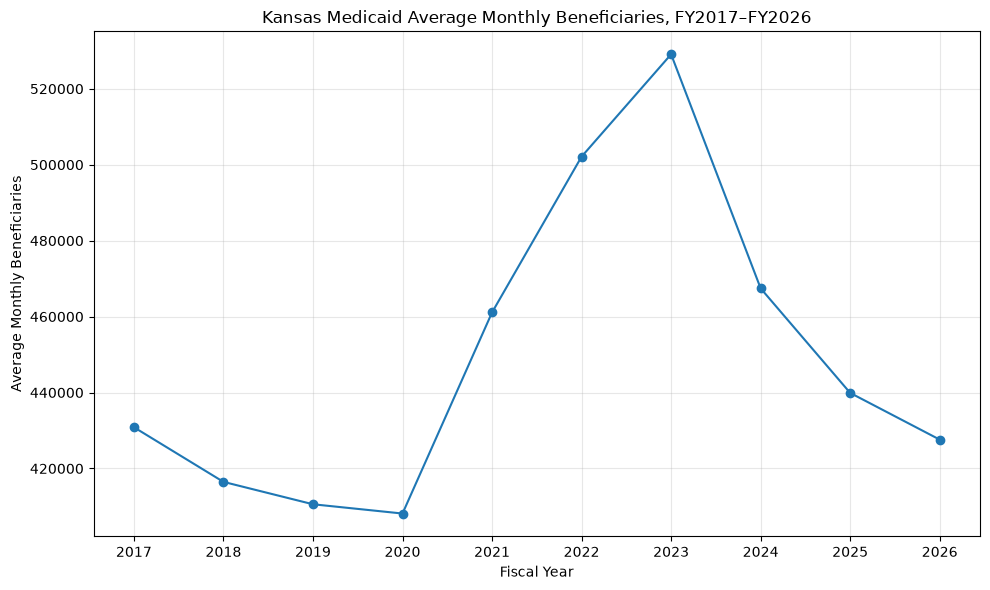

In [2]:
# ---------------------------------------------------------
# ANNUAL MEDICAID BENEFICIARY TREND
# ---------------------------------------------------------

# Create a line chart showing average monthly beneficiaries
# for each fiscal year.
plt.figure(figsize=(10, 6))

plt.plot(
    annual_df["fiscal_year"],
    annual_df["avg_monthly_beneficiaries"],
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Kansas Medicaid Average Monthly Beneficiaries, FY2017–FY2026")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Monthly Beneficiaries")

# Display every fiscal year on the x-axis.
plt.xticks(annual_df["fiscal_year"])

# Add a grid to make year-to-year comparisons easier.
plt.grid(alpha=0.3)

# Prevent labels from being cut off.
plt.tight_layout()

# Display the chart.
plt.show()

In [3]:
# ---------------------------------------------------------
# YEAR-OVER-YEAR CHANGE IN MEDICAID BENEFICIARIES
# ---------------------------------------------------------

# Display fiscal year, average monthly beneficiaries,
# and the year-over-year percentage change.
# This helps quantify the increases and decreases
# that we observed visually in the enrollment chart.
enrollment_change = annual_df[
    [
        "fiscal_year",
        "avg_monthly_beneficiaries",
        "beneficiary_yoy_pct"
    ]
].copy()

# Rename the columns to make the output easier to read.
enrollment_change.columns = [
    "Fiscal Year",
    "Average Monthly Beneficiaries",
    "YoY Change (%)"
]

# Display the completed comparison table.
enrollment_change


,Fiscal Year,Average Monthly Beneficiaries,YoY Change (%)
0,2017,430866.0,NaN
1,2018,416476.0,-3.34
2,2019,410579.0,-1.42
3,2020,408138.0,-0.59
4,2021,461090.0,12.97
5,2022,502118.0,8.90
6,2023,529075.0,5.37
7,2024,467440.0,-11.65
8,2025,439901.0,-5.89
9,2026,427603.0,-2.80


### Interpretation

Kansas Medicaid enrollment declined gradually from FY2017 through FY2020,
then increased substantially from FY2021 through FY2023. Average monthly
beneficiaries peaked in FY2023 at approximately 529,000.

The trend reversed in FY2024, when average monthly enrollment declined by
approximately 11.7%, followed by additional decreases in FY2025 and FY2026.
By FY2026, average monthly enrollment had returned to approximately 428,000,
slightly below its FY2017 level.

## 3. Medicaid Expenditure Trend

This section examines how total annual Kansas Medicaid expenditures changed
from FY2017 through FY2026 and compares the spending pattern with the
enrollment trend identified in the previous section.

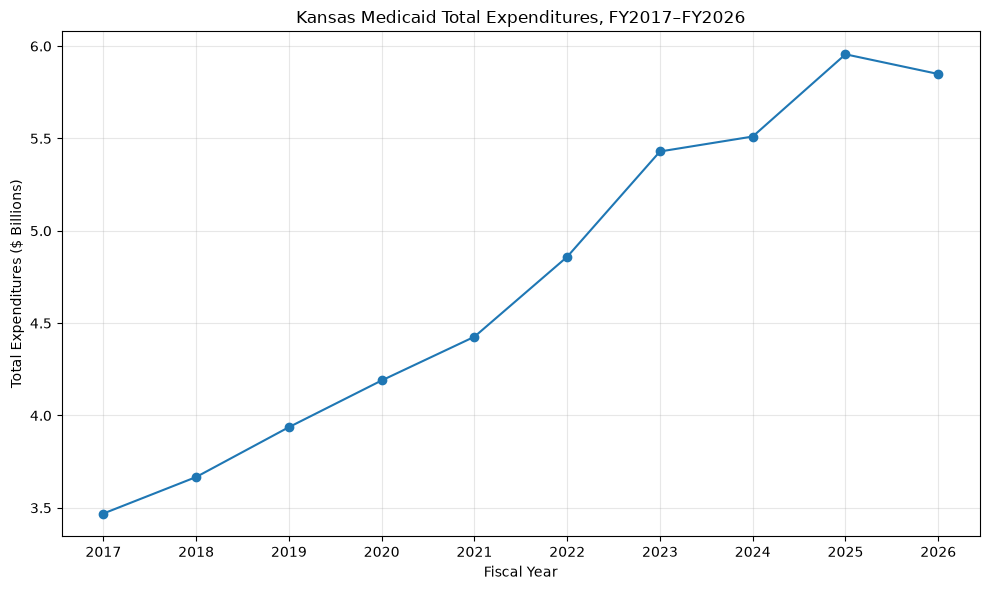

In [4]:
# ---------------------------------------------------------
# ANNUAL MEDICAID EXPENDITURE TREND
# ---------------------------------------------------------

# Create a line chart showing total Medicaid expenditures
# for each fiscal year.
plt.figure(figsize=(10, 6))

plt.plot(
    annual_df["fiscal_year"],
    annual_df["total_expenditures"] / 1_000_000_000,
    marker="o"
)

# Convert expenditures to billions of dollars for readability.
# For example, $3,469,213,635 becomes approximately $3.47 billion.
plt.title("Kansas Medicaid Total Expenditures, FY2017–FY2026")
plt.xlabel("Fiscal Year")
plt.ylabel("Total Expenditures ($ Billions)")

# Display every fiscal year on the x-axis.
plt.xticks(annual_df["fiscal_year"])

# Add a light grid to make year-to-year comparisons easier.
plt.grid(alpha=0.3)

# Prevent labels from being cut off.
plt.tight_layout()

# Display the chart.
plt.show()

In [5]:
# ---------------------------------------------------------
# YEAR-OVER-YEAR CHANGE IN MEDICAID EXPENDITURES
# ---------------------------------------------------------

# Create a smaller table containing the variables needed
# to examine annual Medicaid spending changes.
spending_change = annual_df[
    [
        "fiscal_year",
        "total_expenditures",
        "expenditure_yoy_pct"
    ]
].copy()

# Rename the columns to make the table easier to interpret.
spending_change.columns = [
    "Fiscal Year",
    "Total Expenditures",
    "YoY Change (%)"
]

# Convert total expenditures to billions of dollars
# so the values are easier to read and compare.
spending_change["Total Expenditures ($B)"] = (
    spending_change["Total Expenditures"] / 1_000_000_000
).round(2)

# Remove the original full-dollar column because
# the billions column is easier to interpret for EDA.
spending_change = spending_change.drop(
    columns="Total Expenditures"
)

# Display the year-over-year spending comparison.
spending_change

,Fiscal Year,YoY Change (%),Total Expenditures ($B)
0,2017,NaN,3.47
1,2018,5.70,3.67
2,2019,7.36,3.94
3,2020,6.42,4.19
4,2021,5.65,4.43
5,2022,9.78,4.86
6,2023,11.73,5.43
7,2024,1.49,5.51
8,2025,8.08,5.96
9,2026,-1.79,5.85


### Interpretation

Kansas Medicaid expenditures increased in every fiscal year from FY2017
through FY2025, rising from approximately $3.47 billion to $5.96 billion.
FY2026 was the first year in the study period to show a decline, with total
expenditures decreasing by approximately 1.8% to $5.85 billion.

The expenditure trend differs notably from the enrollment trend. While
enrollment experienced both substantial increases and decreases during the
period, expenditures generally continued to rise.

## 4. Expenditures Relative to Enrollment

Enrollment and total expenditures followed different trends over the study
period. This section examines total annual Medicaid expenditures relative to
the average number of monthly beneficiaries.

In [15]:
# ---------------------------------------------------------
# VALIDATE EXPENDITURE PER BENEFICIARY-MONTH
# ---------------------------------------------------------

# The processed annual dataset already contains:
# - beneficiary_months
# - expenditure_per_beneficiary_month
#
# These variables were created in Notebook 1 during the
# data-processing stage, so Notebook 2 only needs to
# validate and use them for analysis.

annual_df[
    [
        "fiscal_year",
        "beneficiary_months",
        "total_expenditures",
        "expenditure_per_beneficiary_month"
    ]
]

,fiscal_year,beneficiary_months,total_expenditures,expenditure_per_beneficiary_month
0,2017,5170386,3469213635,670.98
1,2018,4997713,3666859078,733.71
2,2019,4926945,3936843520,799.04
3,2020,4897652,4189753837,855.46
4,2021,5533082,4426412757,799.99
5,2022,6025420,4859228793,806.45
6,2023,6348900,5429434410,855.18
7,2024,5609284,5510409877,982.37
8,2025,5278814,5955636294,1128.21
9,2026,5131241,5848965317,1139.87


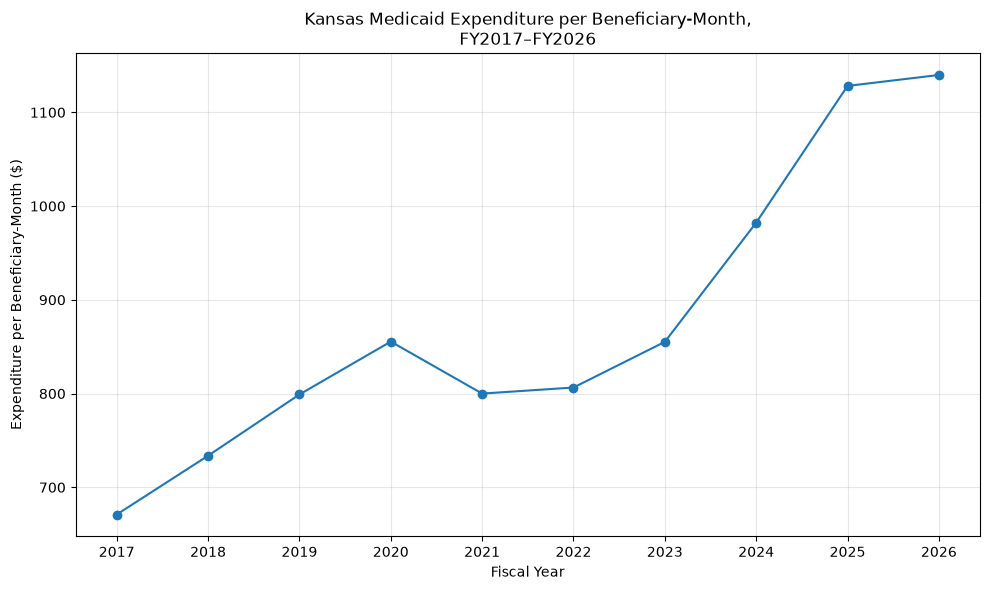

In [7]:
# ---------------------------------------------------------
# EXPENDITURE PER BENEFICIARY-MONTH TREND
# ---------------------------------------------------------

# Create a line chart showing how Medicaid spending
# per beneficiary-month changed across the 10 fiscal years.
plt.figure(figsize=(10, 6))

plt.plot(
    annual_df["fiscal_year"],
    annual_df["expenditure_per_beneficiary_month"],
    marker="o"
)

# Add descriptive chart labels.
plt.title(
    "Kansas Medicaid Expenditure per Beneficiary-Month,\n"
    "FY2017–FY2026"
)

plt.xlabel("Fiscal Year")
plt.ylabel("Expenditure per Beneficiary-Month ($)")

# Display every fiscal year on the x-axis.
plt.xticks(annual_df["fiscal_year"])

# Add a light grid to make year-to-year changes easier to see.
plt.grid(alpha=0.3)

# Prevent chart labels from being cut off.
plt.tight_layout()

# Display the chart.
plt.show()

### Interpretation

Expenditure per beneficiary-month increased from approximately $670.98 in
FY2017 to $1,139.87 in FY2026, an increase of approximately 69.9%.

The measure increased from FY2017 through FY2020, declined in FY2021, and then
resumed an upward trend. The largest sustained increases occurred after
FY2023, reaching approximately $1,128 per beneficiary-month in FY2025 and
$1,140 in FY2026.

This measure represents Medicaid spending relative to beneficiary enrollment
and should be interpreted as spending intensity rather than the actual medical
cost of an individual beneficiary or a measure of program efficiency.

## 5. Enrollment vs. Expenditure Growth

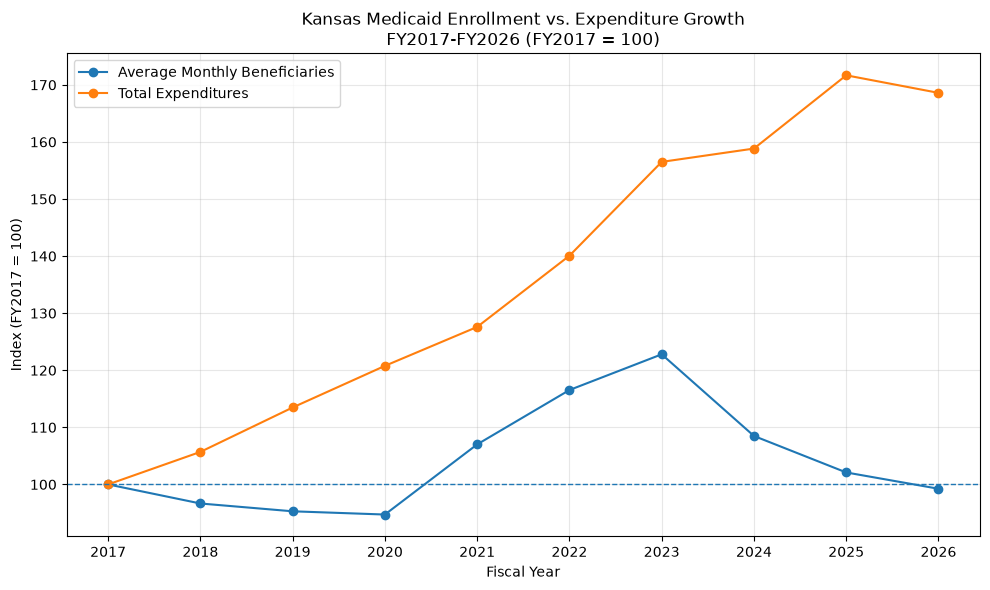

In [8]:
# ---------------------------------------------------------
# INDEXED ENROLLMENT VS EXPENDITURE TREND
# FY2017 = 100
# ---------------------------------------------------------

# Create a copy so we do not modify the original annual dataset.
indexed_df = annual_df.copy()

# Get the FY2017 values that will serve as our baseline.
baseline_beneficiaries = indexed_df.loc[
    indexed_df["fiscal_year"] == 2017,
    "avg_monthly_beneficiaries"
].iloc[0]

baseline_expenditures = indexed_df.loc[
    indexed_df["fiscal_year"] == 2017,
    "total_expenditures"
].iloc[0]

# Convert both measures into indexes where FY2017 = 100.
#
# Example:
# An index of 120 means the value is 20% higher than FY2017.
# An index of 95 means the value is 5% lower than FY2017.
indexed_df["beneficiary_index"] = (
    indexed_df["avg_monthly_beneficiaries"]
    / baseline_beneficiaries
) * 100

indexed_df["expenditure_index"] = (
    indexed_df["total_expenditures"]
    / baseline_expenditures
) * 100

# Create the comparison chart.
plt.figure(figsize=(10, 6))

plt.plot(
    indexed_df["fiscal_year"],
    indexed_df["beneficiary_index"],
    marker="o",
    label="Average Monthly Beneficiaries"
)

plt.plot(
    indexed_df["fiscal_year"],
    indexed_df["expenditure_index"],
    marker="o",
    label="Total Expenditures"
)

# Add a reference line showing the FY2017 baseline.
plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Kansas Medicaid Enrollment vs. Expenditure Growth\n"
    "FY2017-FY2026 (FY2017 = 100)"
)

plt.xlabel("Fiscal Year")
plt.ylabel("Index (FY2017 = 100)")

plt.xticks(indexed_df["fiscal_year"])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Indexing enrollment and expenditures to FY2017 highlights the divergence
between the two measures. Enrollment increased substantially between FY2020
and FY2023 before declining, while expenditures continued to rise throughout
most of the period.

By FY2026, average monthly beneficiaries were approximately 0.8% below the
FY2017 level, while total Medicaid expenditures were approximately 68.6%
higher.

The widening gap between the two indexes shows that expenditure growth over
the 10-year period substantially outpaced enrollment growth. This pattern
motivates the category-of-service analysis in the next section to examine
where recent expenditure changes were concentrated.

## 6. Category-of-Service Analysis

This section examines changes in Medicaid expenditures by category of service,
with a focus on identifying which categories contributed most to the change
in total expenditures from FY2023 to FY2026.

In [9]:
# ---------------------------------------------------------
# LOAD CATEGORY-OF-SERVICE EXPENDITURE DATA
# ---------------------------------------------------------

# Define the path to the processed category dataset
# created in Notebook 1.
category_path = Path(
    "../data/processed/kansas_medicaid_category_expenditures_2018_2026.csv"
)

# Load the processed category expenditure data.
category_df = pd.read_csv(category_path)

# Check that the dataset loaded correctly.
print("Shape:", category_df.shape)

category_df.head()

Shape: (135, 3)


,fiscal_year,category,annual_expenditures
0,2018,Inpatient,112060345
1,2018,Inpatient Hospital-DSH Adjustments,60533406
2,2018,Mental Health Facilities-DSH Adjustments,27670993
3,2018,Outpatient,4687401
4,2018,Pharmacy,12153276


In [10]:
# ---------------------------------------------------------
# PREPARE FY2023 VS FY2026 CATEGORY COMPARISON
# ---------------------------------------------------------

# Remove rows that are totals or components of Managed Care.
# Keeping these would cause double-counting in our analysis.
analysis_categories = category_df[
    ~category_df["category"].isin([
        "Total Expenditures",
        "KDHE (KanCare)",
        "KDADs (KanCare)"
    ])
].copy()

# Extract FY2023 category expenditures.
fy2023 = (
    analysis_categories[
        analysis_categories["fiscal_year"] == 2023
    ][["category", "annual_expenditures"]]
    .rename(
        columns={
            "annual_expenditures": "fy2023_expenditures"
        }
    )
)

# Extract FY2026 category expenditures.
fy2026 = (
    analysis_categories[
        analysis_categories["fiscal_year"] == 2026
    ][["category", "annual_expenditures"]]
    .rename(
        columns={
            "annual_expenditures": "fy2026_expenditures"
        }
    )
)

# Join FY2023 and FY2026 using the category name.
category_change = fy2023.merge(
    fy2026,
    on="category",
    how="inner"
)

# Calculate the absolute expenditure change.
category_change["dollar_change"] = (
    category_change["fy2026_expenditures"]
    - category_change["fy2023_expenditures"]
)

# Display the result as a quick check.
category_change.head()

,category,fy2023_expenditures,fy2026_expenditures,dollar_change
0,Inpatient,123908751,35633962,-88274789
1,Inpatient Hospital-DSH Adjustments,75103746,33830313,-41273433
2,Mental Health Facilities-DSH Adjustments,15511332,8789169,-6722163
3,Outpatient,2052692,3806784,1754092
4,Pharmacy,18028527,28138994,10110467


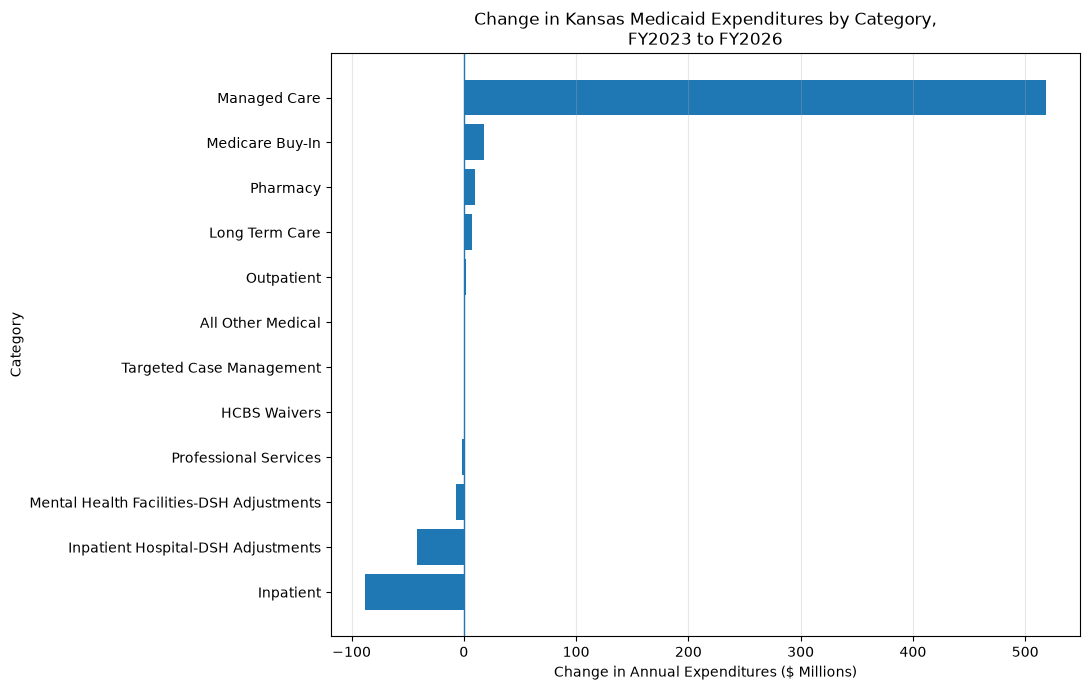

In [11]:
# ---------------------------------------------------------
# CATEGORY CONTRIBUTION TO SPENDING CHANGE
# FY2023 → FY2026
# ---------------------------------------------------------

# Convert dollar changes to millions of dollars.
# This makes the axis much easier to read than displaying
# values such as 518,466,606.
category_change["dollar_change_millions"] = (
    category_change["dollar_change"] / 1_000_000
)

# Sort from the largest decrease to the largest increase.
#
# For a horizontal bar chart, this places the largest
# positive contributor toward the top of the figure.
plot_data = category_change.sort_values(
    "dollar_change_millions",
    ascending=True
)

# Create the figure.
plt.figure(figsize=(11, 7))

# Create one horizontal bar for each expenditure category.
plt.barh(
    plot_data["category"],
    plot_data["dollar_change_millions"]
)

# Add a vertical reference line at zero.
#
# Bars extending right represent spending increases.
# Bars extending left represent spending decreases.
plt.axvline(
    x=0,
    linewidth=1
)

# Add descriptive labels.
plt.title(
    "Change in Kansas Medicaid Expenditures by Category,\n"
    "FY2023 to FY2026"
)
plt.xlabel("Change in Annual Expenditures ($ Millions)")
plt.ylabel("Category")

# Add a light grid only along the numeric axis
# to make dollar differences easier to compare.
plt.grid(
    axis="x",
    alpha=0.3
)

# Prevent long category names from being cut off.
plt.tight_layout()

plt.show()

### Interpretation

From FY2023 to FY2026, Managed Care showed the largest positive expenditure
change, increasing by approximately $518.5 million. This increase was larger
than the program's overall net expenditure increase of approximately
$419.5 million during the same period because decreases in other categories
partially offset the increase.

The largest decreases occurred in Inpatient expenditures, which declined by
approximately $88.3 million, and Inpatient Hospital-DSH expenditures, which
declined by approximately $41.3 million.

These results identify Managed Care as the largest positive category change
during this period, but they do not establish that Managed Care caused the
overall increase in Medicaid expenditures.

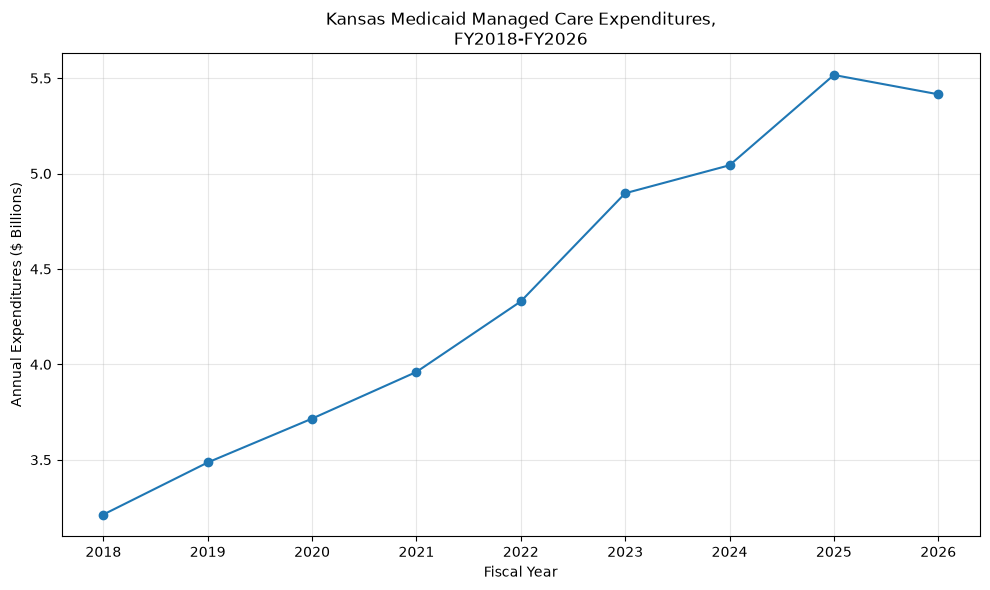

In [12]:
# ---------------------------------------------------------
# MANAGED CARE EXPENDITURE TREND
# FY2018-FY2026
# ---------------------------------------------------------

# Select only the Managed Care category.
managed_care_trend = category_df[
    category_df["category"] == "Managed Care"
].copy()

# Convert expenditures to billions of dollars
# so the chart is easier to interpret.
managed_care_trend["expenditures_billions"] = (
    managed_care_trend["annual_expenditures"] / 1_000_000_000
)

# Create the trend chart.
plt.figure(figsize=(10, 6))

plt.plot(
    managed_care_trend["fiscal_year"],
    managed_care_trend["expenditures_billions"],
    marker="o"
)

plt.title(
    "Kansas Medicaid Managed Care Expenditures,\n"
    "FY2018-FY2026"
)

plt.xlabel("Fiscal Year")
plt.ylabel("Annual Expenditures ($ Billions)")

# Show every fiscal year on the x-axis.
plt.xticks(
    managed_care_trend["fiscal_year"]
)

# Add a light grid to make year-to-year changes
# easier to compare visually.
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Managed Care Trend

Managed Care expenditures increased gradually across FY2018 through FY2026.
The longer-term trend indicates that the higher FY2026 expenditure level
reflects sustained growth over multiple fiscal years rather than a single-year
spike.

In [13]:
# ---------------------------------------------------------
# RECONCILE CATEGORY CHANGES WITH TOTAL EXPENDITURE CHANGE
# FY2023 → FY2026
# ---------------------------------------------------------

# Sum the dollar changes across the independent categories.
#
# Our category_change table already excludes:
# 1. Total Expenditures, because it is the overall total.
# 2. KDHE (KanCare) and KDADS (KanCare), because they are
#    components of Managed Care and would cause double-counting.
category_change_total = category_change["dollar_change"].sum()


# Get the official category-page total expenditures for FY2023.
fy2023_total = category_df.loc[
    (category_df["fiscal_year"] == 2023)
    & (category_df["category"] == "Total Expenditures"),
    "annual_expenditures"
].iloc[0]


# Get the official category-page total expenditures for FY2026.
fy2026_total = category_df.loc[
    (category_df["fiscal_year"] == 2026)
    & (category_df["category"] == "Total Expenditures"),
    "annual_expenditures"
].iloc[0]


# Calculate the actual change in total Medicaid expenditures.
official_total_change = fy2026_total - fy2023_total


# Compare the sum of individual category changes with
# the change calculated from the official annual totals.
reconciliation_difference = (
    category_change_total - official_total_change
)


# Display the results with comma separators for readability.
print(
    f"Sum of category changes: "
    f"${category_change_total:,.0f}"
)

print(
    f"Official total expenditure change: "
    f"${official_total_change:,.0f}"
)

print(
    f"Reconciliation difference: "
    f"${reconciliation_difference:,.0f}"
)

Sum of category changes: $419,530,908
Official total expenditure change: $419,530,908
Reconciliation difference: $0


### Category Expenditure Reconciliation

The sum of expenditure changes across independent service categories from
FY2023 to FY2026 exactly matches the change in reported Total Expenditures:
$419,530,908.

KDHE (KanCare) and KDADS (KanCare) were excluded from the category sum because
they are components of Managed Care and including them would double-count
expenditures.

This reconciliation provides an additional validation check for the extracted
category-of-service data.

## 7. Ten-Year Summary

This section summarizes the overall change in Medicaid enrollment, total
expenditures, and expenditure per beneficiary-month between FY2017 and FY2026.

In [14]:
# ---------------------------------------------------------
# 10-YEAR HEADLINE KPI SUMMARY
# FY2017 → FY2026
# ---------------------------------------------------------

# Get the first and last fiscal-year records.
fy2017 = annual_df[
    annual_df["fiscal_year"] == 2017
].iloc[0]

fy2026 = annual_df[
    annual_df["fiscal_year"] == 2026
].iloc[0]

# Calculate the percentage change in average monthly beneficiaries.
beneficiary_change_pct = (
    (fy2026["avg_monthly_beneficiaries"]
     - fy2017["avg_monthly_beneficiaries"])
    / fy2017["avg_monthly_beneficiaries"]
) * 100

# Calculate the percentage change in total expenditures.
expenditure_change_pct = (
    (fy2026["total_expenditures"]
     - fy2017["total_expenditures"])
    / fy2017["total_expenditures"]
) * 100

# Calculate the percentage change in expenditure
# per beneficiary-month.
spending_intensity_change_pct = (
    (fy2026["expenditure_per_beneficiary_month"]
     - fy2017["expenditure_per_beneficiary_month"])
    / fy2017["expenditure_per_beneficiary_month"]
) * 100

# Display the three headline changes.
print(
    f"Average Monthly Beneficiaries: "
    f"{beneficiary_change_pct:.1f}%"
)

print(
    f"Total Medicaid Expenditures: "
    f"{expenditure_change_pct:.1f}%"
)

print(
    f"Expenditure per Beneficiary-Month: "
    f"{spending_intensity_change_pct:.1f}%"
)

Average Monthly Beneficiaries: -0.8%
Total Medicaid Expenditures: 68.6%
Expenditure per Beneficiary-Month: 69.9%


### Ten-Year Summary

Across FY2017 through FY2026, average monthly Medicaid enrollment decreased
slightly by approximately 0.8%, while total expenditures increased by
approximately 68.6%.

Over the same period, expenditure per beneficiary-month increased by
approximately 69.9%. Together, these measures show that the long-term growth
in Medicaid expenditures substantially exceeded the change in beneficiary
enrollment.

The analysis does not determine the causes of this divergence, but the
category-of-service analysis shows that Managed Care represented the largest
positive category change during the more recent FY2023-to-FY2026 period.

## 8. Key Findings

### Key Findings

- Average monthly Medicaid beneficiaries were nearly unchanged over the full
  period, decreasing by approximately 0.8% from FY2017 to FY2026.

- Total Medicaid expenditures increased by approximately 68.6% over the same
  period, rising from about $3.47 billion in FY2017 to about $5.85 billion in
  FY2026.

- Expenditure per beneficiary-month increased by approximately 69.9%, from
  about $670.98 in FY2017 to about $1,139.87 in FY2026.

- Enrollment increased sharply between FY2020 and FY2023, then declined in
  FY2024 through FY2026. Despite the decline in enrollment after FY2023,
  total expenditures remained elevated.

- From FY2023 to FY2026, total Medicaid expenditures increased by approximately
  $419.5 million. Managed Care represented the largest positive category
  change, increasing by approximately $518.5 million.

- Several categories partially offset that increase. Inpatient expenditures
  decreased by approximately $88.3 million, while Inpatient Hospital-DSH
  expenditures decreased by approximately $41.3 million.

- Managed Care expenditures show a sustained upward trend from FY2018 through
  FY2026 rather than a single-year increase.

## 9. Limitations

### Limitations

- Expenditure per beneficiary-month is a measure of spending relative to
  enrollment. It should not be interpreted as the actual medical cost of an
  individual beneficiary or as a measure of program efficiency or healthcare
  quality.

- The analysis is descriptive and does not establish why expenditures or
  enrollment changed. Factors such as policy changes, inflation, reimbursement
  rates, service utilization, population characteristics, and changes in the
  mix of services were not independently evaluated.

- Category-of-service trend analysis begins in FY2018 because the reporting
  structure changed between FY2017 and FY2018, limiting direct category-level
  comparisons across the full 10-year period.

- Some category definitions and labels changed across reports. Categories were
  standardized where appropriate for comparison, but differences in reporting
  definitions may affect interpretation of individual category trends.

- The FY2026 sum of the 12 extracted monthly expenditure totals differs from
  the published annual total by $1. The published annual total was retained
  for category-level validation, while the discrepancy is considered
  immaterial to the overall analysis.

- All findings are based on publicly reported Kansas Medicaid administrative
  data and should be interpreted within the definitions and reporting
  conventions used in the source reports.